In [1]:
import json
import pandas as pd


In [3]:
csv_file_path = path = '../data/chapters.csv'
df = pd.read_csv(csv_file_path)
df.head()


,chapter,volume,name,page,date,jump
0,1,1.0,Romance Dawn,53,1997-07-19,1997 Issue 34
1,2,1.0,"They Call Him ""Straw Hat Luffy""",23,1997-07-28,1997 Issue 35
2,3,1.0,Enter Zolo: Pirate Hunter,21,1997-08-04,1997 Issue 36
3,4,1.0,The Great Captain Morgan,19,1997-08-11,1997 Issue 37-38
4,5,1.0,The King of the Pirates and the Master Swordsman,19,1997-08-25,1997 Issue 39


In [4]:
first = df.iloc[0]['date']
print(first)


1997-07-19


In [5]:
from datetime import datetime
def convert_to_datetime(date_string):
    return datetime.strptime(date_string, "%Y-%m-%d")

# Apply the conversion function to the entire column
df['real_date'] = df['date'].apply(convert_to_datetime)
print(df.iloc[0]['real_date'])


1997-07-19 00:00:00


In [11]:
# Compute the time difference between consecutive rows
df['break_days'] =  df['real_date'].shift(-1) - df['real_date']
print(df.head(10))


   chapter  volume                                              name  page  \
0        1     1.0                                      Romance Dawn    53   
1        2     1.0                   They Call Him "Straw Hat Luffy"    23   
2        3     1.0                         Enter Zolo: Pirate Hunter    21   
3        4     1.0                          The Great Captain Morgan    19   
4        5     1.0  The King of the Pirates and the Master Swordsman    19   
5        6     1.0                                        Number One    23   
6        7     1.0                                           Friends    20   
7        8     1.0                                              Nami    19   
8        9     2.0                                      Femme Fatale    21   
9       10     2.0                            Incident at the Tavern    23   

         date              jump  real_date break_days  
0  1997-07-19     1997 Issue 34 1997-07-19     9 days  
1  1997-07-28     1997 Issue 

In [14]:
delta = pd.to_timedelta('14 days')
break_more_than_two_weeks = (df['break_days'] > delta).sum()
print(break_more_than_two_weeks)


44


In [29]:
delta = pd.to_timedelta('21 days')
condition = df['break_days'] > delta

result_df = df.loc[condition].sort_values(by='break_days', ascending=False)
print(len(result_df))
print(result_df[['name','real_date', 'break_days']].sort_values(by='real_date'))


3
                 name  real_date break_days
596              3D2Y 2010-08-30    35 days
1052     New Emperors 2022-06-20    35 days
1085  The Five Elders 2023-06-12    35 days


In [25]:
# Extract the year from 'date_column' and count occurrences
year_counts = df['real_date'].dt.year.value_counts().sort_index()
print(year_counts)


real_date
1997    21
1998    48
1999    48
2000    48
2001    48
2002    46
2003    45
2004    45
2005    45
2006    45
2007    44
2008    43
2009    42
2010    40
2011    42
2012    43
2013    39
2014    39
2015    39
2016    40
2017    39
2018    39
2019    38
2020    33
2021    36
2022    35
2023    28
Name: count, dtype: int64


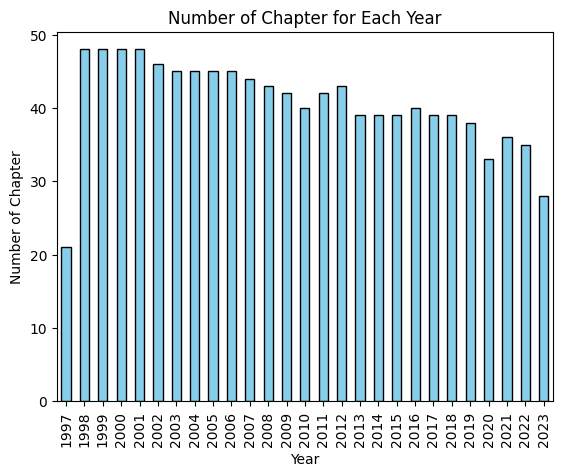

In [27]:
import matplotlib.pyplot as plt

year_counts = df['real_date'].dt.year.value_counts().sort_index()

# Plot the result as a bar plot
year_counts.plot(kind='bar', color='skyblue', edgecolor='black')

# Set plot labels and title
plt.xlabel('Year')
plt.ylabel('Number of Chapter')
plt.title('Number of Chapter for Each Year')

# Show the plot
plt.show()


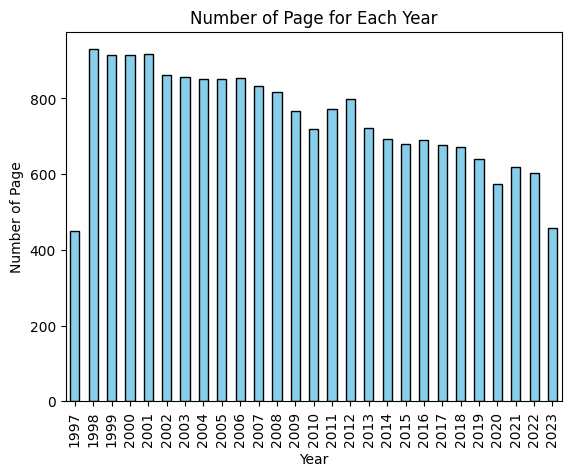

In [31]:
sum_per_year = df.groupby(df['real_date'].dt.year)['page'].sum()

# Plot the result as a bar plot
sum_per_year.plot(kind='bar', color='skyblue', edgecolor='black')

# Set plot labels and title
plt.xlabel('Year')
plt.ylabel('Number of Page')
plt.title('Number of Page for Each Year')

# Show the plot
plt.show()


In [32]:
total_page = df['page'].sum()
print(total_page)


20138


In [35]:
duration = df['real_date'].max() - df['real_date'].min()
print(duration)


9613 days 00:00:00


In [38]:
days = duration.total_seconds() // 86400
work_days = days * 5 // 7

print(f'Days: {days}')
print(f'Working: {work_days}')

print(f'Pages per day: {total_page / work_days}')


Days: 9613.0
Working: 6866.0
Pages per day: 2.933003204194582
